# Notebook 05: Prescriptive Analysis

### 1. GlucoVision Analytics

This notebook focuses on prescriptive analysis using the cleaned glucose monitoring dataset.

The goal is not only to describe what happened, but to recommend actions based on glucose patterns, patient-level risk, and time-based trends.

This notebook will create:
- Patient risk segmentation
- Recommendation rules
- Time-of-day glucose risk insights
- Patient-level action categories
- Dashboard-ready output files

### 2. Import Libraries

Why this step is important

Importing libraries and setting chart styles at the beginning keeps the notebook clean and consistent.

Consequence if skipped

Charts may look inconsistent, and repeated imports/settings may clutter the notebook.

In [154]:
# Core libraries
import pandas as pd
import numpy as np
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Chart styling
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="tab10"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

### 3. Set Project Paths

Why this step is important

Using paths makes the notebook reproducible and organized.

Consequence if skipped

Files may be saved in the wrong place, making the GitHub project harder to maintain.

In [155]:
# Define project paths
DATA_DIR = "../data/processed"
OUTPUT_DIR = "../outputs"

# Create outputs folder if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

cleaned_data_path = os.path.join(DATA_DIR, "glucovision_cleaned_preprocessed.csv")
patient_summary_path = os.path.join(DATA_DIR, "patient_summary.csv")

print("Cleaned data path:", cleaned_data_path)
print("Patient summary path:", patient_summary_path)
print("Output directory:", OUTPUT_DIR)

Cleaned data path: ../data/processed\glucovision_cleaned_preprocessed.csv
Patient summary path: ../data/processed\patient_summary.csv
Output directory: ../outputs


### 4. Load Processed Data

Why this step is important

Prescriptive analysis should use the cleaned and processed dataset, not raw data.

Consequence if skipped

Using raw data may lead to incorrect recommendations because missing values, time issues, or engineered features may not be handled.

In [156]:
df = pd.read_csv(cleaned_data_path)
patient_summary = pd.read_csv(patient_summary_path)

print("Cleaned dataset shape:", df.shape)
print("Patient summary shape:", patient_summary.shape)

df.head()

Cleaned dataset shape: (309392, 23)
Patient summary shape: (25, 9)


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,is_low_glucose,is_high_glucose,glucose_category,hour,day,day_of_week,date,month,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P,NaN,False,True,High,18,13,Wednesday,2018-06-13,6,NaN,NaN,NaN,332.000000,332.000000
1,2018-06-13 18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,332.0,NaN,NaN,329.000000,329.000000
2,2018-06-13 18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,326.0,NaN,NaN,329.333333,329.333333
3,2018-06-13 18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,18,13,Wednesday,2018-06-13,6,330.0,332.0,NaN,328.000000,328.000000
4,2018-06-13 19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P,0 days 00:05:00,False,True,High,19,13,Wednesday,2018-06-13,6,324.0,326.0,NaN,323.600000,323.600000


In [157]:
patient_summary.head()

,patient_id,start_time,end_time,total_records,avg_glucose,min_glucose,max_glucose,low_glucose_events,high_glucose_events
0,HUPA0001P,2018-06-13 18:40:00,2018-06-27 23:55:00,4096,181.443726,40.0,444.0,59,1723
1,HUPA0002P,2018-06-13 22:45:00,2018-06-24 23:45:00,3181,113.469664,40.0,310.0,759,466
2,HUPA0003P,2018-06-13 21:40:00,2018-06-26 23:45:00,3770,143.273519,44.0,366.0,265,954
3,HUPA0004P,2018-07-09 15:30:00,2018-07-20 16:45:00,3184,180.377984,40.0,411.0,309,1448
4,HUPA0005P,2018-07-09 14:20:00,2018-07-22 23:45:00,3858,147.698624,40.0,379.0,114,973


### 5. Validate Data Columns

Why this step is important

Before building recommendation logic, we must confirm that required columns exist.

Consequence if skipped

The notebook may fail later with errors such as `KeyError`.

In [158]:
print("Cleaned dataset columns:")
print(df.columns.tolist())

print("\nPatient summary columns:")
print(patient_summary.columns.tolist())

Cleaned dataset columns:
['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'patient_id', 'time_diff', 'is_low_glucose', 'is_high_glucose', 'glucose_category', 'hour', 'day', 'day_of_week', 'date', 'month', 'glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6', 'glucose_rolling_30min', 'glucose_rolling_1hr']

Patient summary columns:
['patient_id', 'start_time', 'end_time', 'total_records', 'avg_glucose', 'min_glucose', 'max_glucose', 'low_glucose_events', 'high_glucose_events']


In [159]:
required_columns = [
    "patient_id",
    "time",
    "glucose",
    "hour",
    "day_of_week",
    "glucose_category"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Missing required columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


### 6. Convert Time Column

Why this step is important

Time-based analysis requires the time column to be in datetime format.

Consequence if skipped

Time-based grouping, sorting, and trend analysis may not work correctly.

In [160]:
df["time"] = pd.to_datetime(df["time"])

print(df["time"].dtype)
df[["patient_id", "time", "glucose"]].head()

datetime64[us]


,patient_id,time,glucose
0,HUPA0001P,2018-06-13 18:40:00,332.0
1,HUPA0001P,2018-06-13 18:45:00,326.0
2,HUPA0001P,2018-06-13 18:50:00,330.0
3,HUPA0001P,2018-06-13 18:55:00,324.0
4,HUPA0001P,2018-06-13 19:00:00,306.0


### 7. Review Glucose Category Distribution

Why this step is important

This shows how often patients fall into low, normal, high, or very high glucose ranges.

Consequence if skipped

The recommendation logic would not be grounded in actual glucose distribution.

In [161]:
glucose_category_counts = (
    df["glucose_category"]
    .value_counts()
    .reset_index()
)

glucose_category_counts.columns = ["glucose_category", "record_count"]

glucose_category_counts

,glucose_category,record_count
0,Normal,221892
1,High,67123
2,Low,20377


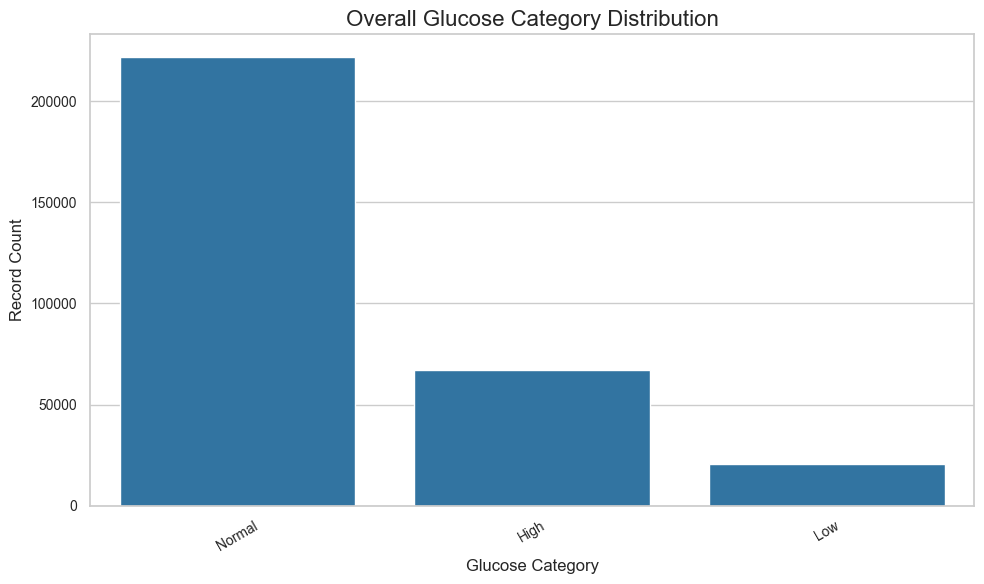

In [162]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=glucose_category_counts,
    x="glucose_category",
    y="record_count"
)

plt.title("Overall Glucose Category Distribution")
plt.xlabel("Glucose Category")
plt.ylabel("Record Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 8. Create Patient-Level Risk Metrics

Why this step is important

Patient-level metrics help identify which patients need closer attention.

Consequence if skipped

Recommendations would be too general and not personalized by patient risk.

In [163]:
patient_risk = df.groupby("patient_id").agg(
    total_records=("glucose", "count"),
    avg_glucose=("glucose", "mean"),
    min_glucose=("glucose", "min"),
    max_glucose=("glucose", "max"),
    glucose_std=("glucose", "std"),
    hypoglycemia_count=("glucose_category", lambda x: (x == "Hypoglycemia").sum()),
    normal_count=("glucose_category", lambda x: (x == "Normal").sum()),
    hyperglycemia_count=("glucose_category", lambda x: (x == "Hyperglycemia").sum()),
    severe_hyperglycemia_count=("glucose_category", lambda x: (x == "Severe Hyperglycemia").sum())
).reset_index()

patient_risk.head()

,patient_id,total_records,avg_glucose,min_glucose,max_glucose,glucose_std,hypoglycemia_count,normal_count,hyperglycemia_count,severe_hyperglycemia_count
0,HUPA0001P,4096,181.443726,40.0,444.0,70.644633,0,2314,0,0
1,HUPA0002P,3181,113.469664,40.0,310.0,59.145068,0,1956,0,0
2,HUPA0003P,3770,143.273519,44.0,366.0,61.326542,0,2551,0,0
3,HUPA0004P,3184,180.377984,40.0,411.0,83.020747,0,1427,0,0
4,HUPA0005P,3858,147.698624,40.0,379.0,49.791133,0,2771,0,0


In [164]:
patient_risk["hypoglycemia_pct"] = (
    patient_risk["hypoglycemia_count"] / patient_risk["total_records"] * 100
)

patient_risk["hyperglycemia_pct"] = (
    (patient_risk["hyperglycemia_count"] + patient_risk["severe_hyperglycemia_count"])
    / patient_risk["total_records"] * 100
)

patient_risk["normal_pct"] = (
    patient_risk["normal_count"] / patient_risk["total_records"] * 100
)

patient_risk.head()

,patient_id,total_records,avg_glucose,min_glucose,max_glucose,glucose_std,hypoglycemia_count,normal_count,hyperglycemia_count,severe_hyperglycemia_count,hypoglycemia_pct,hyperglycemia_pct,normal_pct
0,HUPA0001P,4096,181.443726,40.0,444.0,70.644633,0,2314,0,0,0.0,0.0,56.494141
1,HUPA0002P,3181,113.469664,40.0,310.0,59.145068,0,1956,0,0,0.0,0.0,61.490097
2,HUPA0003P,3770,143.273519,44.0,366.0,61.326542,0,2551,0,0,0.0,0.0,67.665782
3,HUPA0004P,3184,180.377984,40.0,411.0,83.020747,0,1427,0,0,0.0,0.0,44.817839
4,HUPA0005P,3858,147.698624,40.0,379.0,49.791133,0,2771,0,0,0.0,0.0,71.824780


### 9. Patient Risk Segmentation Logic

Why this step is important

Risk segmentation converts numeric glucose metrics into understandable patient groups.

Consequence if skipped

Dashboard users may see numbers but not understand which patients require attention.

In [165]:
def assign_risk_segment(row):
    """
    Assign patient risk segment based on glucose patterns.
    """

    if row["hypoglycemia_pct"] >= 10:
        return "High Risk - Frequent Hypoglycemia"

    elif row["hyperglycemia_pct"] >= 40:
        return "High Risk - Frequent Hyperglycemia"

    elif row["glucose_std"] >= 50:
        return "Moderate Risk - High Variability"

    elif row["normal_pct"] >= 70:
        return "Lower Risk - Mostly Stable"

    else:
        return "Moderate Risk - Needs Monitoring"

In [166]:
patient_risk["risk_segment"] = patient_risk.apply(assign_risk_segment, axis=1)

patient_risk[[
    "patient_id",
    "avg_glucose",
    "glucose_std",
    "hypoglycemia_pct",
    "hyperglycemia_pct",
    "normal_pct",
    "risk_segment"
]].head()

,patient_id,avg_glucose,glucose_std,hypoglycemia_pct,hyperglycemia_pct,normal_pct,risk_segment
0,HUPA0001P,181.443726,70.644633,0.0,0.0,56.494141,Moderate Risk - High Variability
1,HUPA0002P,113.469664,59.145068,0.0,0.0,61.490097,Moderate Risk - High Variability
2,HUPA0003P,143.273519,61.326542,0.0,0.0,67.665782,Moderate Risk - High Variability
3,HUPA0004P,180.377984,83.020747,0.0,0.0,44.817839,Moderate Risk - High Variability
4,HUPA0005P,147.698624,49.791133,0.0,0.0,71.824780,Lower Risk - Mostly Stable


### 10. Visualize Risk Segment Distribution

In [167]:
risk_segment_counts = (
    patient_risk["risk_segment"]
    .value_counts()
    .reset_index()
)

risk_segment_counts.columns = ["risk_segment", "patient_count"]

risk_segment_counts

,risk_segment,patient_count
0,Moderate Risk - High Variability,17
1,Lower Risk - Mostly Stable,7
2,Moderate Risk - Needs Monitoring,1


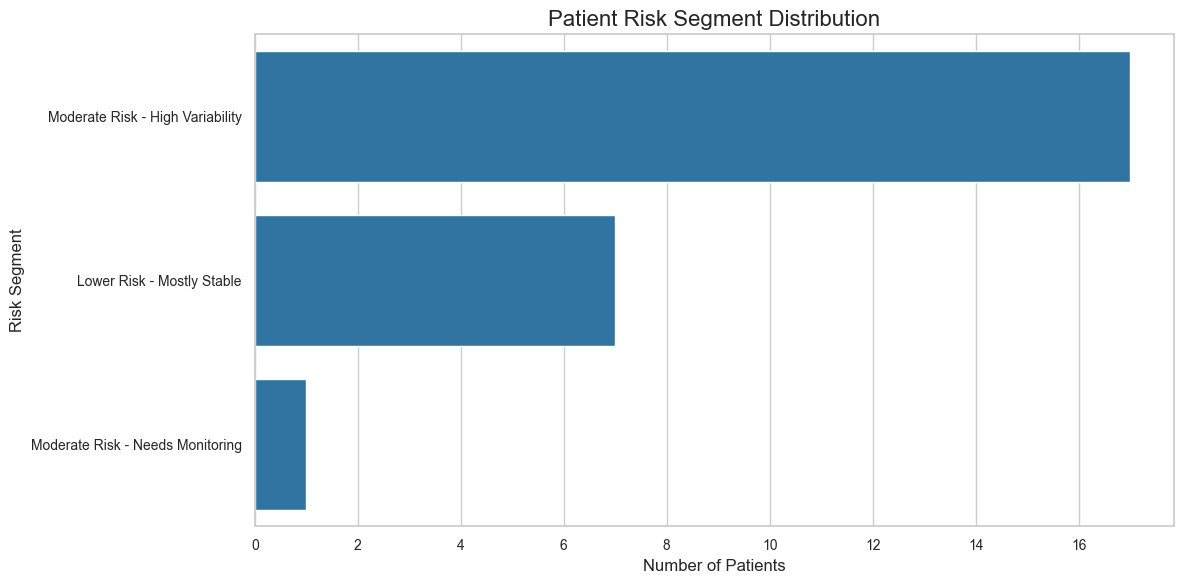

In [168]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=risk_segment_counts,
    y="risk_segment",
    x="patient_count"
)

plt.title("Patient Risk Segment Distribution")
plt.xlabel("Number of Patients")
plt.ylabel("Risk Segment")
plt.tight_layout()
plt.show()

### Dashboard Insight

This chart can be used in the Streamlit dashboard to quickly show how many patients fall into each risk category.

### 11. Time-of-Day Risk Analysis

Why this step is important

Time-of-day analysis helps identify when glucose risk is higher.

Consequence if skipped

The dashboard would miss useful prescriptive insights such as morning, afternoon, or overnight risk patterns.

In [169]:
hourly_risk = df.groupby("hour").agg(
    avg_glucose=("glucose", "mean"),
    record_count=("glucose", "count"),
    hypoglycemia_count=("glucose_category", lambda x: (x == "Hypoglycemia").sum()),
    hyperglycemia_count=("glucose_category", lambda x: ((x == "Hyperglycemia") | (x == "Severe Hyperglycemia")).sum())
).reset_index()

hourly_risk["hypoglycemia_pct"] = (
    hourly_risk["hypoglycemia_count"] / hourly_risk["record_count"] * 100
)

hourly_risk["hyperglycemia_pct"] = (
    hourly_risk["hyperglycemia_count"] / hourly_risk["record_count"] * 100
)

hourly_risk.head()

,hour,avg_glucose,record_count,hypoglycemia_count,hyperglycemia_count,hypoglycemia_pct,hyperglycemia_pct
0,0,142.560453,12842,0,0,0.0,0.0
1,1,138.743205,12852,0,0,0.0,0.0
2,2,137.456326,12852,0,0,0.0,0.0
3,3,138.166504,12852,0,0,0.0,0.0
4,4,139.117531,12852,0,0,0.0,0.0


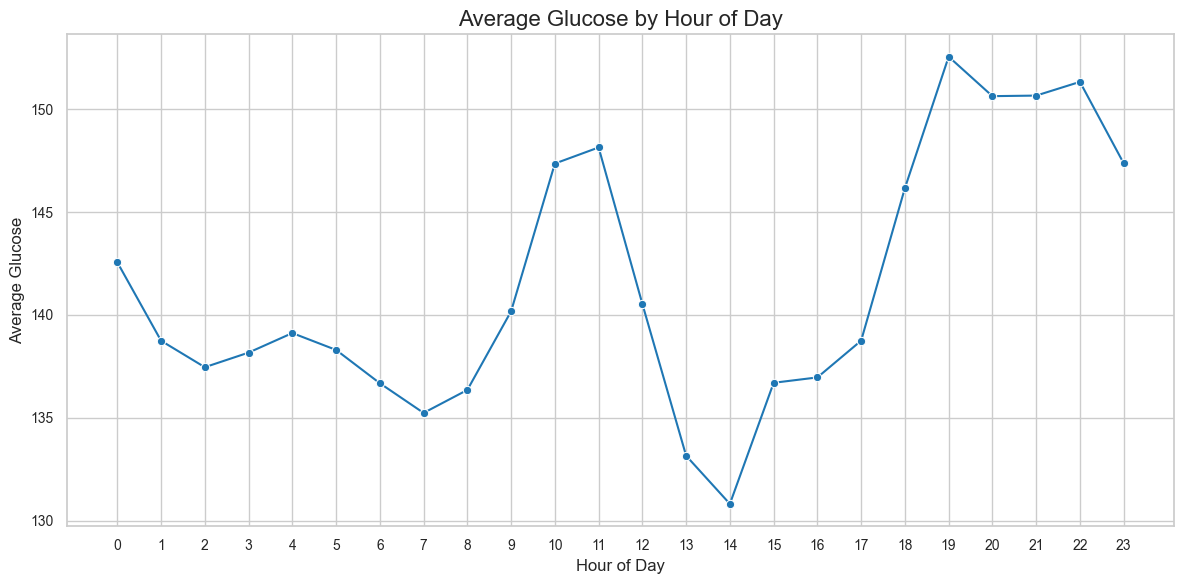

In [170]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_risk,
    x="hour",
    y="avg_glucose",
    marker="o"
)

plt.title("Average Glucose by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Glucose")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

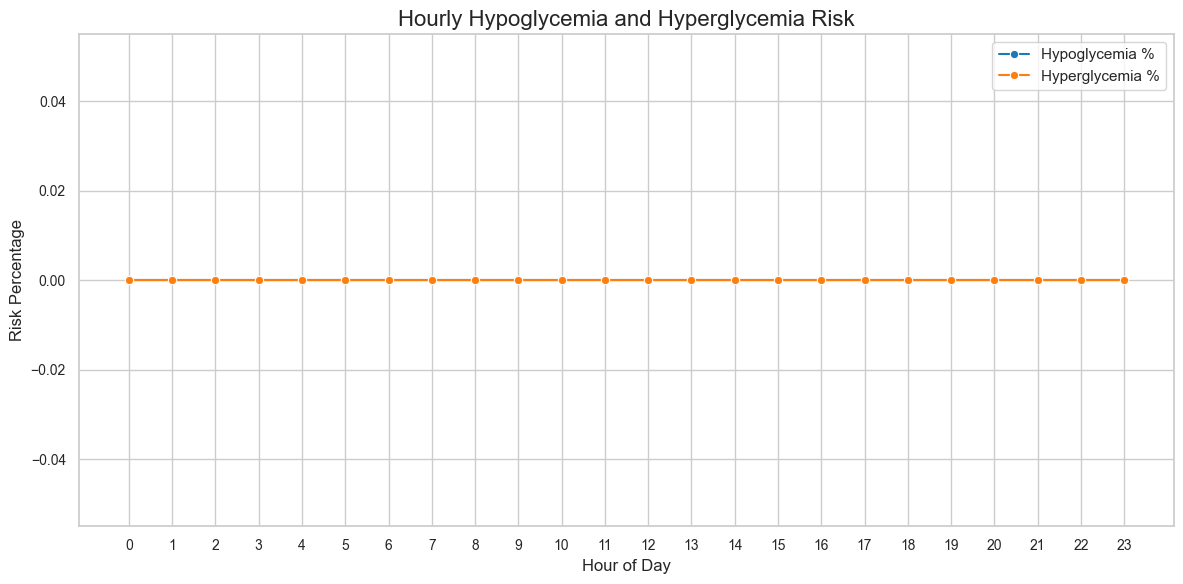

In [171]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_risk,
    x="hour",
    y="hypoglycemia_pct",
    marker="o",
    label="Hypoglycemia %"
)

sns.lineplot(
    data=hourly_risk,
    x="hour",
    y="hyperglycemia_pct",
    marker="o",
    label="Hyperglycemia %"
)

plt.title("Hourly Hypoglycemia and Hyperglycemia Risk")
plt.xlabel("Hour of Day")
plt.ylabel("Risk Percentage")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

### 12. Create Time-Based Recommendation Rules

Why this step is important

This converts hourly analysis into clear dashboard-ready recommendations.

Consequence if skipped

Users may see trends but not understand what actions to consider.

In [172]:
def assign_time_recommendation(row):
    """
    Assign recommendation based on hourly glucose risk.
    """

    if row["hypoglycemia_pct"] >= 10:
        return "Monitor for low glucose risk during this hour"

    elif row["hyperglycemia_pct"] >= 40:
        return "Review meals, activity, or medication timing around this hour"

    elif row["avg_glucose"] > 180:
        return "Average glucose is high during this hour"

    else:
        return "Glucose pattern appears relatively stable"

In [173]:
hourly_risk["time_recommendation"] = hourly_risk.apply(assign_time_recommendation, axis=1)

hourly_risk[[
    "hour",
    "avg_glucose",
    "hypoglycemia_pct",
    "hyperglycemia_pct",
    "time_recommendation"
]]

,hour,avg_glucose,hypoglycemia_pct,hyperglycemia_pct,time_recommendation
0,0,142.560453,0.0,0.0,Glucose pattern appears relatively stable
1,1,138.743205,0.0,0.0,Glucose pattern appears relatively stable
2,2,137.456326,0.0,0.0,Glucose pattern appears relatively stable
3,3,138.166504,0.0,0.0,Glucose pattern appears relatively stable
4,4,139.117531,0.0,0.0,Glucose pattern appears relatively stable
5,5,138.296633,0.0,0.0,Glucose pattern appears relatively stable
6,6,136.677204,0.0,0.0,Glucose pattern appears relatively stable
7,7,135.232969,0.0,0.0,Glucose pattern appears relatively stable
8,8,136.351311,0.0,0.0,Glucose pattern appears relatively stable
9,9,140.178077,0.0,0.0,Glucose pattern appears relatively stable


### 13. Patient-Level Recommendation Logic

In [174]:
def assign_patient_recommendation(row):
    """
    Assign patient-level recommendation based on risk segment.
    """

    if row["risk_segment"] == "High Risk - Frequent Hypoglycemia":
        return "Prioritize low glucose prevention. Review meal timing, activity patterns, and insulin-related factors with a healthcare professional."

    elif row["risk_segment"] == "High Risk - Frequent Hyperglycemia":
        return "Focus on reducing high glucose exposure. Review post-meal glucose patterns, medication timing, and lifestyle factors with a healthcare professional."

    elif row["risk_segment"] == "Moderate Risk - High Variability":
        return "Monitor glucose variability. Investigate inconsistent meals, activity levels, stress, or medication timing."

    elif row["risk_segment"] == "Lower Risk - Mostly Stable":
        return "Maintain current glucose management habits and continue routine monitoring."

    else:
        return "Continue monitoring and review glucose patterns periodically."

In [175]:
patient_risk["recommendation"] = patient_risk.apply(assign_patient_recommendation, axis=1)

patient_risk[[
    "patient_id",
    "risk_segment",
    "recommendation"
]].head()

,patient_id,risk_segment,recommendation
0,HUPA0001P,Moderate Risk - High Variability,Monitor glucose variability. Investigate incon...
1,HUPA0002P,Moderate Risk - High Variability,Monitor glucose variability. Investigate incon...
2,HUPA0003P,Moderate Risk - High Variability,Monitor glucose variability. Investigate incon...
3,HUPA0004P,Moderate Risk - High Variability,Monitor glucose variability. Investigate incon...
4,HUPA0005P,Lower Risk - Mostly Stable,Maintain current glucose management habits and...


### Important Note

These recommendations are analytical suggestions only. They are not medical advice. Any treatment decisions should be made with a qualified healthcare professional.

### 14. Identify Highest-Risk Patients

In [176]:
df["glucose_category"].value_counts()

glucose_category
Normal    221892
High       67123
Low        20377
Name: count, dtype: int64

In [177]:
patient_risk = df.groupby("patient_id").agg(
    total_records=("glucose", "count"),
    avg_glucose=("glucose", "mean"),
    min_glucose=("glucose", "min"),
    max_glucose=("glucose", "max"),
    glucose_std=("glucose", "std"),

    hypoglycemia_count=("glucose_category", lambda x: (x == "Low").sum()),
    normal_count=("glucose_category", lambda x: (x == "Normal").sum()),
    hyperglycemia_count=("glucose_category", lambda x: (x == "High").sum())
).reset_index()

In [178]:
patient_risk["hypoglycemia_pct"] = (
    patient_risk["hypoglycemia_count"] / patient_risk["total_records"] * 100
)

patient_risk["hyperglycemia_pct"] = (
    patient_risk["hyperglycemia_count"] / patient_risk["total_records"] * 100
)

patient_risk["normal_pct"] = (
    patient_risk["normal_count"] / patient_risk["total_records"] * 100
)

In [179]:
patient_risk[[
    "patient_id",
    "hypoglycemia_pct",
    "hyperglycemia_pct",
    "normal_pct"
]].head()

,patient_id,hypoglycemia_pct,hyperglycemia_pct,normal_pct
0,HUPA0001P,1.440430,42.065430,56.494141
1,HUPA0002P,23.860421,14.649481,61.490097
2,HUPA0003P,7.029178,25.305040,67.665782
3,HUPA0004P,9.704774,45.477387,44.817839
4,HUPA0005P,2.954899,25.220321,71.824780


In [180]:
hourly_risk = df.groupby("hour").agg(
    avg_glucose=("glucose", "mean"),
    record_count=("glucose", "count"),
    hypoglycemia_count=("glucose_category", lambda x: (x == "Low").sum()),
    hyperglycemia_count=("glucose_category", lambda x: (x == "High").sum())
).reset_index()

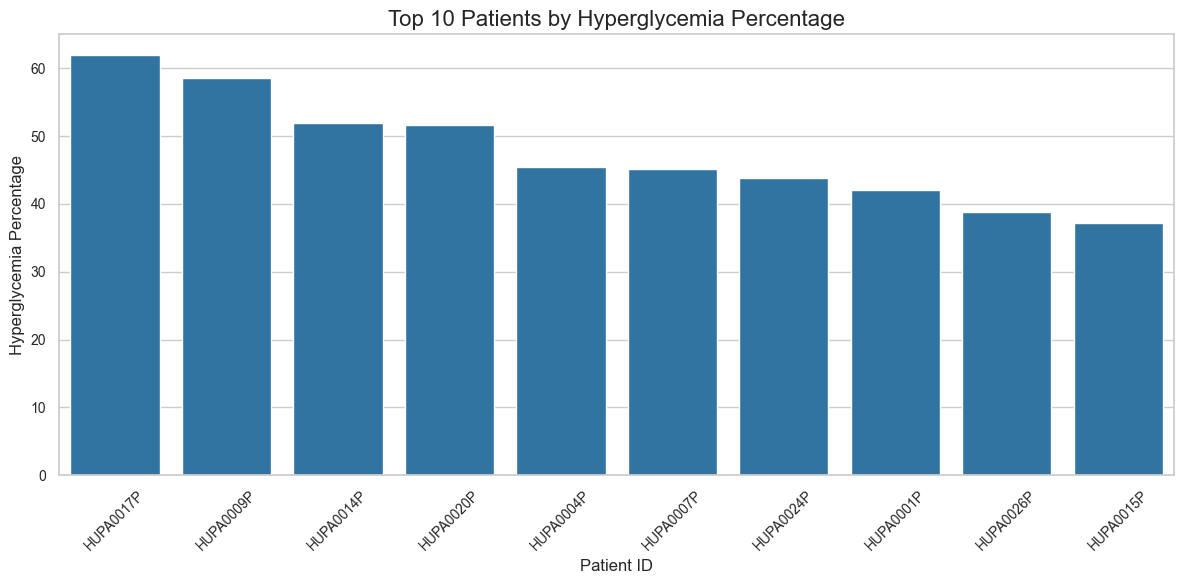

In [181]:
top_hyperglycemia_patients = patient_risk.sort_values(
    by="hyperglycemia_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_hyperglycemia_patients,
    x="patient_id",
    y="hyperglycemia_pct"
)

plt.title("Top 10 Patients by Hyperglycemia Percentage")
plt.xlabel("Patient ID")
plt.ylabel("Hyperglycemia Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Dashboard Insight

This output can support a dashboard section called “Patients Requiring Attention”.

### 15. Glucose Variability Analysis

Why this step is important

High glucose variability may indicate unstable glucose control even when average glucose looks acceptable.

Consequence if skipped

Patients with unstable glucose patterns may be missed.

In [182]:
def assign_risk_segment(row):

    if row["hypoglycemia_pct"] >= 5:
        return "High Risk - Frequent Hypoglycemia"

    elif row["hyperglycemia_pct"] >= 15:
        return "High Risk - Frequent Hyperglycemia"

    elif row["glucose_std"] >= 35:
        return "Moderate Risk - High Variability"

    elif row["normal_pct"] >= 70:
        return "Lower Risk - Mostly Stable"

    else:
        return "Moderate Risk - Needs Monitoring"


patient_risk["risk_segment"] = patient_risk.apply(
    assign_risk_segment,
    axis=1
)

In [183]:
patient_variability = patient_risk.sort_values(
    by="glucose_std",
    ascending=False
)

patient_variability[[
    "patient_id",
    "avg_glucose",
    "glucose_std",
    "risk_segment"
]].head(10)

,patient_id,avg_glucose,glucose_std,risk_segment
5,HUPA0006P,165.204585,84.736079,High Risk - Frequent Hypoglycemia
3,HUPA0004P,180.377984,83.020747,High Risk - Frequent Hypoglycemia
12,HUPA0016P,150.208344,79.837161,High Risk - Frequent Hypoglycemia
16,HUPA0020P,194.282669,78.785656,High Risk - Frequent Hyperglycemia
6,HUPA0007P,173.151991,78.656646,High Risk - Frequent Hypoglycemia
10,HUPA0014P,188.061765,72.458599,High Risk - Frequent Hyperglycemia
0,HUPA0001P,181.443726,70.644633,High Risk - Frequent Hyperglycemia
14,HUPA0018P,143.677664,70.269565,High Risk - Frequent Hypoglycemia
13,HUPA0017P,200.795244,69.448526,High Risk - Frequent Hyperglycemia
22,HUPA0026P,162.985267,68.665216,High Risk - Frequent Hypoglycemia


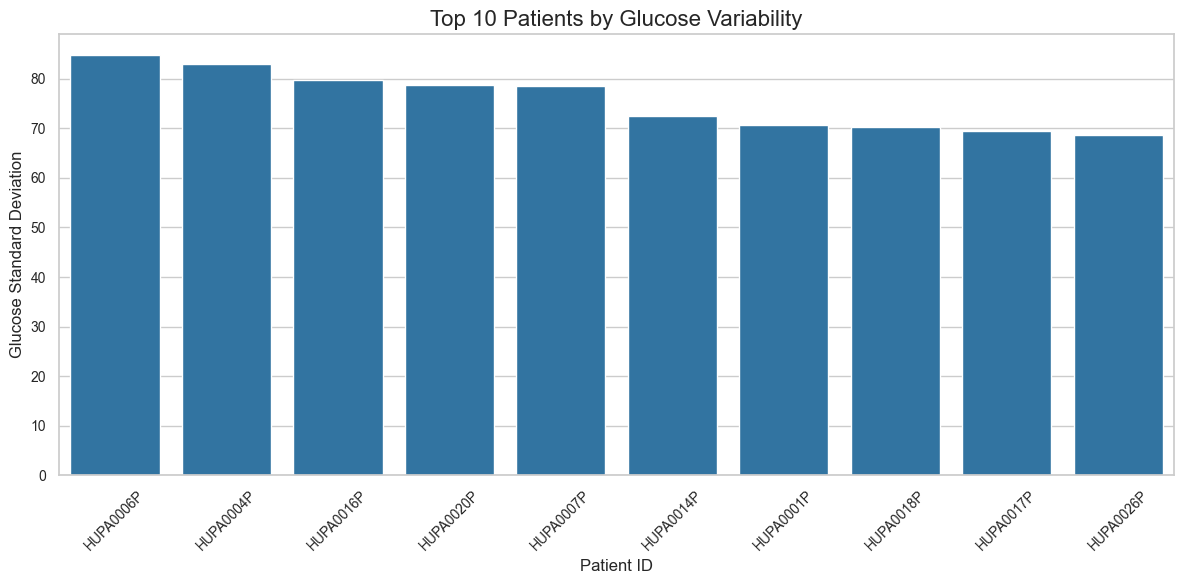

In [184]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=patient_variability.head(10),
    x="patient_id",
    y="glucose_std"
)

plt.title("Top 10 Patients by Glucose Variability")
plt.xlabel("Patient ID")
plt.ylabel("Glucose Standard Deviation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 16. Create Prescriptive Priority Score

Why this step is important

A priority score helps rank patients for dashboard display.

Hypoglycemia is weighted higher because low glucose episodes can require urgent attention.

Consequence if skipped

The dashboard may show risk categories but not clearly rank patients by urgency.

In [185]:
def assign_patient_recommendation(row):

    if row["risk_segment"] == "High Risk - Frequent Hypoglycemia":
        return "Prioritize low glucose prevention. Review meal timing, activity patterns, and insulin-related factors with a healthcare professional."

    elif row["risk_segment"] == "High Risk - Frequent Hyperglycemia":
        return "Focus on reducing high glucose exposure. Review post-meal glucose patterns, medication timing, and lifestyle factors with a healthcare professional."

    elif row["risk_segment"] == "Moderate Risk - High Variability":
        return "Monitor glucose variability. Investigate inconsistent meals, activity levels, stress, or medication timing."

    elif row["risk_segment"] == "Lower Risk - Mostly Stable":
        return "Maintain current glucose management habits and continue routine monitoring."

    else:
        return "Continue monitoring and review glucose patterns periodically."


patient_risk["recommendation"] = patient_risk.apply(
    assign_patient_recommendation,
    axis=1
)

In [186]:
patient_risk["priority_score"] = (
    patient_risk["hypoglycemia_pct"] * 2.0
    + patient_risk["hyperglycemia_pct"] * 1.5
    + patient_risk["glucose_std"] * 0.5
)

patient_risk = patient_risk.sort_values(
    by="priority_score",
    ascending=False
)

patient_risk[[
    "patient_id",
    "priority_score",
    "risk_segment",
    "recommendation"
]].head(10)

,patient_id,priority_score,risk_segment,recommendation
13,HUPA0017P,132.362496,High Risk - Frequent Hyperglycemia,Focus on reducing high glucose exposure. Revie...
3,HUPA0004P,129.136002,High Risk - Frequent Hypoglycemia,Prioritize low glucose prevention. Review meal...
6,HUPA0007P,125.003718,High Risk - Frequent Hypoglycemia,Prioritize low glucose prevention. Review meal...
16,HUPA0020P,124.036434,High Risk - Frequent Hyperglycemia,Focus on reducing high glucose exposure. Revie...
10,HUPA0014P,122.165575,High Risk - Frequent Hyperglycemia,Focus on reducing high glucose exposure. Revie...
12,HUPA0016P,119.853391,High Risk - Frequent Hypoglycemia,Prioritize low glucose prevention. Review meal...
14,HUPA0018P,116.906284,High Risk - Frequent Hypoglycemia,Prioritize low glucose prevention. Review meal...
20,HUPA0024P,114.596294,High Risk - Frequent Hypoglycemia,Prioritize low glucose prevention. Review meal...
5,HUPA0006P,112.651882,High Risk - Frequent Hypoglycemia,Prioritize low glucose prevention. Review meal...
7,HUPA0009P,110.882857,High Risk - Frequent Hyperglycemia,Focus on reducing high glucose exposure. Revie...


### 17. Visualize Priority Score

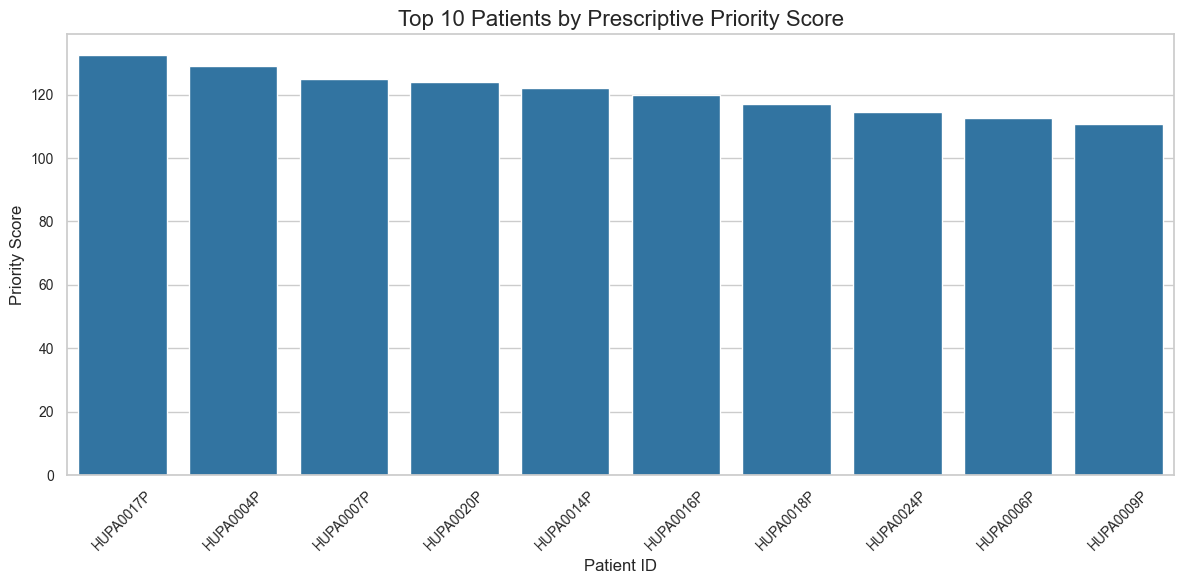

In [187]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=patient_risk.head(10),
    x="patient_id",
    y="priority_score"
)

plt.title("Top 10 Patients by Prescriptive Priority Score")
plt.xlabel("Patient ID")
plt.ylabel("Priority Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 18. Dashboard-Oriented Summary Metrics

In [188]:
dashboard_summary = {
    "total_patients": patient_risk["patient_id"].nunique(),
    "high_risk_patients": patient_risk["risk_segment"].str.contains("High Risk").sum(),
    "moderate_risk_patients": patient_risk["risk_segment"].str.contains("Moderate Risk").sum(),
    "lower_risk_patients": patient_risk["risk_segment"].str.contains("Lower Risk").sum(),
    "avg_priority_score": patient_risk["priority_score"].mean()
}

dashboard_summary_df = pd.DataFrame([dashboard_summary])

dashboard_summary_df

,total_patients,high_risk_patients,moderate_risk_patients,lower_risk_patients,avg_priority_score
0,25,24,1,0,93.354071


### Dashboard Insight

These values can be shown as KPI cards in Streamlit.

### 19. Save Prescriptive Analysis Outputs

Why this step is important

Saving outputs allows the Streamlit dashboard to use prescriptive results directly.

Consequence if skipped

The dashboard would need to recompute everything every time, making it less efficient and harder to manage.

In [189]:
patient_risk_output_path = os.path.join(OUTPUT_DIR, "patient_risk_segmentation.csv")
hourly_risk_output_path = os.path.join(OUTPUT_DIR, "hourly_risk_recommendations.csv")
dashboard_summary_output_path = os.path.join(OUTPUT_DIR, "prescriptive_dashboard_summary.csv")

patient_risk.to_csv(patient_risk_output_path, index=False)
hourly_risk.to_csv(hourly_risk_output_path, index=False)
dashboard_summary_df.to_csv(dashboard_summary_output_path, index=False)

print("Saved:", patient_risk_output_path)
print("Saved:", hourly_risk_output_path)
print("Saved:", dashboard_summary_output_path)

Saved: ../outputs\patient_risk_segmentation.csv
Saved: ../outputs\hourly_risk_recommendations.csv
Saved: ../outputs\prescriptive_dashboard_summary.csv


## Key Findings

1. Patients were segmented into risk groups based on hypoglycemia percentage, hyperglycemia percentage, glucose variability, and normal glucose percentage.

2. High-risk patients were identified using rule-based logic.

3. Time-of-day analysis showed when glucose risk is more likely to occur.

4. A prescriptive priority score was created to rank patients by attention level.

5. Dashboard-ready CSV files were saved for future Streamlit integration.

## Dashboard Recommendations

The Streamlit dashboard should include:

- KPI cards for total patients, high-risk patients, moderate-risk patients, and lower-risk patients
- Risk segment distribution chart
- Top patients by priority score
- Hourly glucose risk trends
- Patient-level recommendation table
- Filters by patient ID and risk segment

## Important Disclaimer

This analysis is intended for educational and analytical purposes only. It does not provide medical diagnosis or treatment advice.